In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/adult.csv")

In [3]:
df.shape

(32561, 15)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# EDA

# Take insightful information about numerical features

In [5]:
df[['education.num','education']].sample(50)

,education.num,education
26766,10,Some-college
21854,9,HS-grad
13358,9,HS-grad
32252,8,12th
13555,9,HS-grad
11525,9,HS-grad
3822,10,Some-college
17317,10,Some-college
3301,13,Bachelors
18497,9,HS-grad


In [6]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [7]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
df.select_dtypes(include='int64').sum()

,0
age,1256257
fnlwgt,6179373392
education.num,328237
capital.gain,35089324
capital.loss,2842700
hours.per.week,1316684


In [10]:
df.select_dtypes(include='object')

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
0,?,HS-grad,Widowed,?,Not-in-family,White,Female,United-States,<=50K
1,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,United-States,<=50K
2,?,Some-college,Widowed,?,Unmarried,Black,Female,United-States,<=50K
3,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,United-States,<=50K
4,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,United-States,<=50K
...,...,...,...,...,...,...,...,...,...
32556,Private,Some-college,Never-married,Protective-serv,Not-in-family,White,Male,United-States,<=50K
32557,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,United-States,<=50K
32558,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,>50K
32559,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K


In [11]:
df['education.num'].unique()

array([ 9, 10,  4,  6, 16, 15, 13, 14,  7, 12, 11,  2,  3,  8,  5,  1])

In [12]:
for i in range (1,16):
    df1=df.query(f"`education.num` =={i}")
    print(i,df1["education"].unique())

1 ['Preschool']
2 ['1st-4th']
3 ['5th-6th']
4 ['7th-8th']
5 ['9th']
6 ['10th']
7 ['11th']
8 ['12th']
9 ['HS-grad']
10 ['Some-college']
11 ['Assoc-voc']
12 ['Assoc-acdm']
13 ['Bachelors']
14 ['Masters']
15 ['Prof-school']


In [13]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [14]:
print(df["hours.per.week"].max())
print(df["hours.per.week"].min())

99
1


In [15]:
df["capital.gain"].value_counts()

,count
capital.gain,
0,29849
15024,347
7688,284
7298,246
99999,159
...,...
2538,1
2387,1
1455,1


In [16]:
df[["age","age","capital.gain","workclass","education","occupation"]].sample(10)

,age,age,capital.gain,workclass,education,occupation
29594,38,38,0,Private,Bachelors,Exec-managerial
3512,40,40,3464,?,HS-grad,?
22501,32,32,0,Local-gov,Masters,Prof-specialty
15049,31,31,0,Self-emp-not-inc,Bachelors,Sales
7865,26,26,0,Private,HS-grad,Machine-op-inspct
11887,34,34,0,Private,HS-grad,Exec-managerial
229,34,34,0,Private,Some-college,Transport-moving
22806,79,79,0,Private,Bachelors,Sales
25152,29,29,0,State-gov,Masters,Prof-specialty
22424,59,59,0,Private,HS-grad,Adm-clerical


In [17]:
df["capital.loss"].value_counts()

,count
capital.loss,
0,31042
1902,202
1977,168
1887,159
1848,51
...,...
1944,1
2080,1
1539,1


In [18]:
print((df["capital.loss"]>0).sum())
print((df["capital.gain"]>0).sum())

1519
2712


In [19]:
df.shape

(32561, 15)

In [20]:
df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


After understand the fnlwgt column it is just weight not more for predictive features

# Take insightful information about categorical features

In [21]:
print(df["native.country"].nunique())
print("_____________________________________________")
print(df["native.country"].value_counts())

42
_____________________________________________
native.country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34


In [22]:
df["workclass"].unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [23]:
for workclass in df["workclass"].dropna().unique():
    print("\n Workclass :",workclass)
    print(df.loc[df["workclass"]==workclass,["income","age"]])


 Workclass : ?
      income  age
0      <=50K   90
2      <=50K   66
14      >50K   51
24     <=50K   61
44     <=50K   71
...      ...  ...
32533   >50K   35
32534  <=50K   30
32541   >50K   71
32543  <=50K   41
32544  <=50K   72

[1836 rows x 2 columns]

 Workclass : Private
      income  age
1      <=50K   82
3      <=50K   54
4      <=50K   41
5      <=50K   34
6      <=50K   38
...      ...  ...
32556  <=50K   22
32557  <=50K   27
32558   >50K   40
32559  <=50K   58
32560  <=50K   22

[22696 rows x 2 columns]

 Workclass : State-gov
      income  age
7       >50K   74
52      >50K   51
121     >50K   68
132     >50K   68
146    <=50K   60
...      ...  ...
32382  <=50K   58
32399  <=50K   48
32485  <=50K   64
32542  <=50K   45
32550  <=50K   43

[1298 rows x 2 columns]

 Workclass : Federal-gov
      income  age
8      <=50K   68
35      >50K   63
87      >50K   43
163    <=50K   57
171    <=50K   57
...      ...  ...
32292   >50K   39
32340  <=50K   23
32402  <=50K   28
32405   

In [24]:
df.select_dtypes(include='object').sample(1)

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
19916,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,>50K


"Understand marital.status column"

In [25]:
print(df["marital.status"].unique())
print("_________________________________________")
print(df["marital.status"].value_counts())

['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
_________________________________________
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64


In [26]:
for workclass in df["marital.status"].dropna().unique():
    print("\n Workclass :",workclass)
    print(df.loc[df["marital.status"]==workclass,["income","age"]])


 Workclass : Widowed
      income  age
0      <=50K   90
1      <=50K   82
2      <=50K   66
12      >50K   52
31      >50K   59
...      ...  ...
32437  <=50K   61
32456  <=50K   53
32469  <=50K   62
32473  <=50K   66
32559  <=50K   58

[993 rows x 2 columns]

 Workclass : Divorced
      income  age
3      <=50K   54
5      <=50K   34
8      <=50K   68
10      >50K   45
15      >50K   46
...      ...  ...
32537  <=50K   37
32545  <=50K   45
32546  <=50K   31
32548  <=50K   37
32550  <=50K   43

[4443 rows x 2 columns]

 Workclass : Separated
      income  age
4      <=50K   41
6      <=50K   38
13      >50K   32
19      >50K   34
21     <=50K   29
...      ...  ...
32487  <=50K   52
32514  <=50K   32
32532  <=50K   29
32542  <=50K   45
32543  <=50K   41

[1025 rows x 2 columns]

 Workclass : Never-married
      income  age
7       >50K   74
9       >50K   41
11      >50K   38
14      >50K   51
18      >50K   22
...      ...  ...
32539   >50K   34
32540  <=50K   30
32554  <=50K   32
3

In [27]:
print(df["occupation"].unique())
print("_________________________________________")
print(df["occupation"].value_counts())

['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
_________________________________________
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


In [28]:
print(df["relationship"].unique())
print("_________________________________________")
print(df["relationship"].value_counts())

['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']
_________________________________________
relationship
Husband           13193
Not-in-family      8305
Own-child          5068
Unmarried          3446
Wife               1568
Other-relative      981
Name: count, dtype: int64


In [29]:
for relation in df["relationship"].dropna().unique():
    print("\n Relation-type :",relation)
    print(df.loc[df["relationship"]==relation,["age","income","sex","native.country","education"]])


 Relation-type : Not-in-family
       age income     sex native.country     education
0       90  <=50K  Female  United-States       HS-grad
1       82  <=50K  Female  United-States       HS-grad
8       68  <=50K  Female  United-States       HS-grad
11      38   >50K    Male  United-States   Prof-school
12      52   >50K  Female  United-States     Bachelors
...    ...    ...     ...            ...           ...
32543   41  <=50K  Female  United-States       HS-grad
32546   31  <=50K  Female  United-States       Masters
32548   37  <=50K  Female  United-States    Assoc-acdm
32554   32  <=50K    Male         Taiwan       Masters
32556   22  <=50K    Male  United-States  Some-college

[8305 rows x 5 columns]

 Relation-type : Unmarried
       age income     sex native.country     education
2       66  <=50K  Female  United-States  Some-college
3       54  <=50K  Female  United-States       7th-8th
5       34  <=50K  Female  United-States       HS-grad
6       38  <=50K    Male  United-S

In [30]:
print("__________Sex____________")
print(df["sex"].value_counts())
print("__________race____________")
print(df["race"].value_counts())

__________Sex____________
sex
Male      21790
Female    10771
Name: count, dtype: int64
__________race____________
race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


# understanding data is complete

# let's start Detect patterns

Check those column which contain null value

In [31]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [32]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# take insight from data through visualization

# UNIVARIATE ANALYSIS

income
<=50K    24720
>50K      7841
Name: count, dtype: int64


<Axes: ylabel='count'>

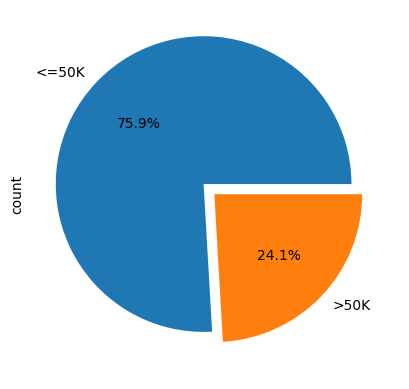

In [33]:
print(df["income"].value_counts())
df["income"].value_counts().plot.pie(autopct='%1.1f%%',explode=[0.1,0])

Make new dataframe of sex column for saw the no. of category

In [34]:
df["sex"].value_counts().reset_index()

,sex,count
0,Male,21790
1,Female,10771


21790.0
10771.0


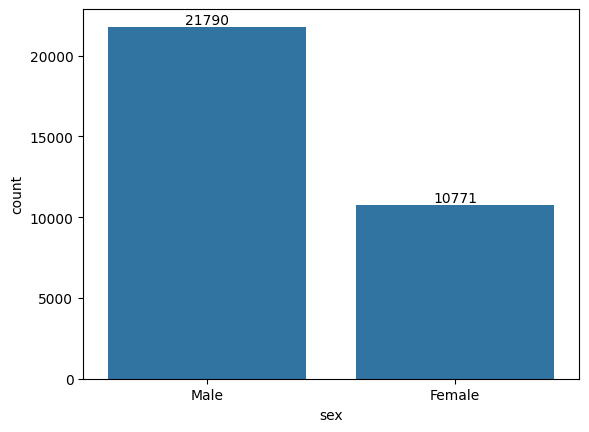

In [35]:
value_count=df["sex"].value_counts().reset_index()
ax=sns.barplot(x="sex",y="count",data=value_count)
for container in ax.containers:
    ax.bar_label(container)
    for bar in container:
        print(bar.get_height())

<Axes: ylabel='count'>

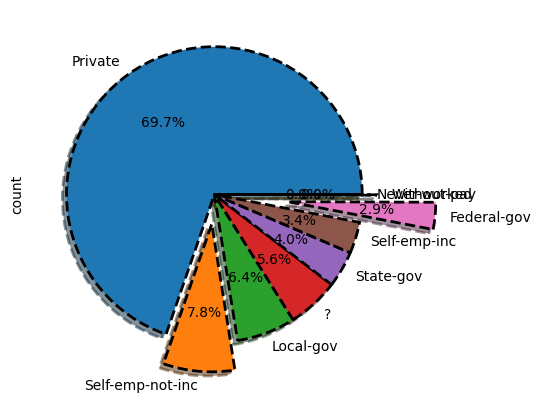

In [36]:
df["workclass"].value_counts().plot.pie(autopct='%1.1f%%',explode=[0,0.2,0,0,0,0,0.5,0.10,0],wedgeprops={'edgecolor':'black','linewidth':2,'linestyle':'--'},shadow=True)

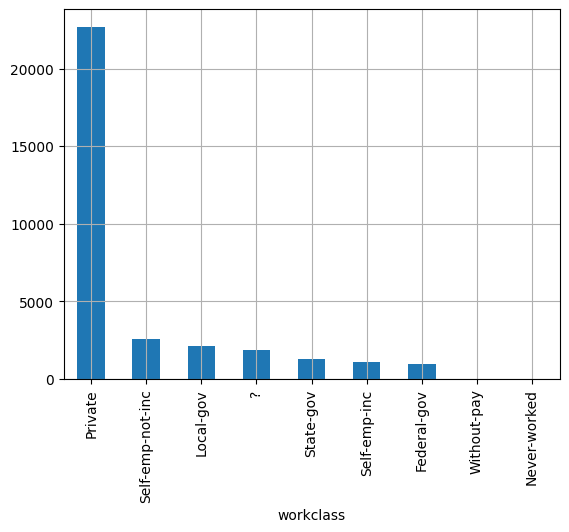

In [37]:
df["workclass"].value_counts().plot.bar()
plt.grid(True)

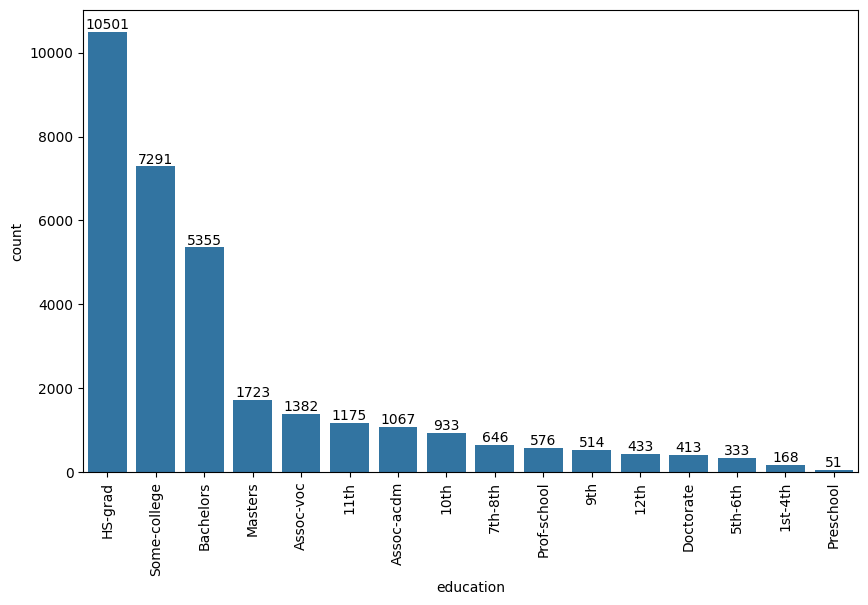

In [38]:
plt.figure(figsize=(10,6))
value=df["education"].value_counts().reset_index()
ax=sns.barplot(x="education",y="count",data=value)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=90)
plt.show()

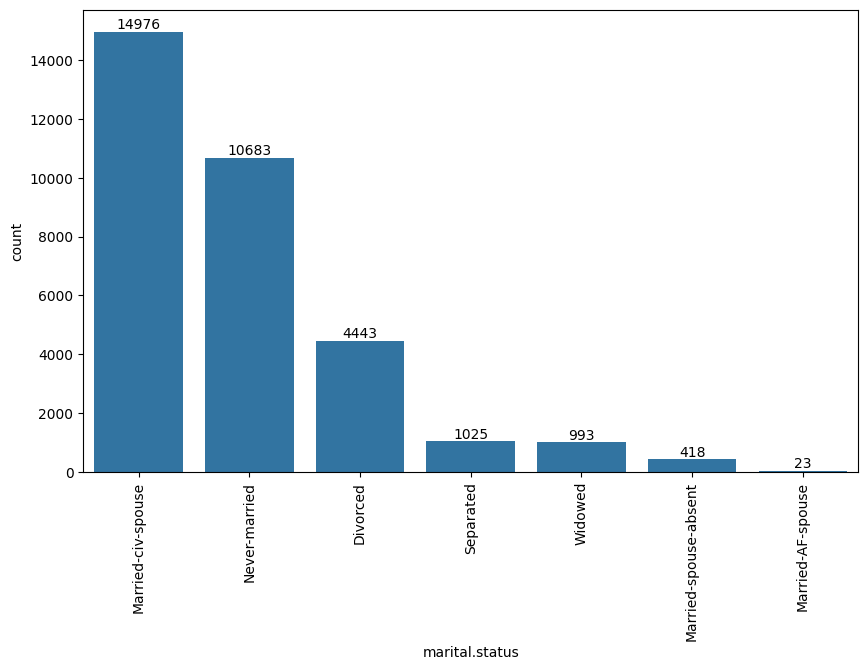

In [39]:
plt.figure(figsize=(10,6))
value=df["marital.status"].value_counts().reset_index()
ax=sns.barplot(x="marital.status",y="count",data=value)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=90)
plt.show()

<Axes: ylabel='count'>

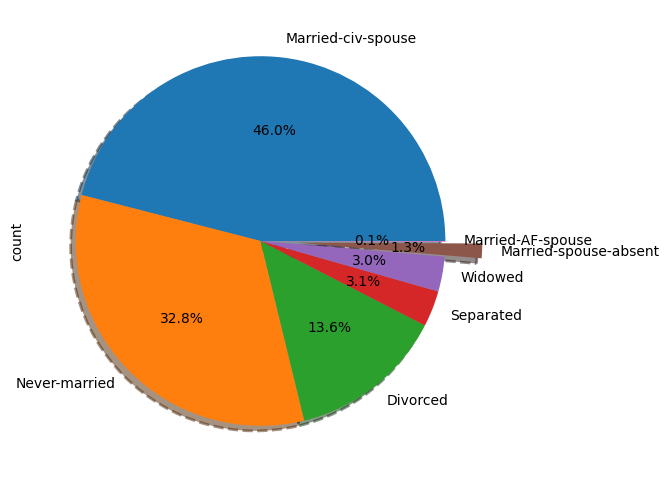

In [40]:
plt.figure(figsize=(10,6))
df["marital.status"].value_counts().plot.pie(autopct='%1.1f%%',explode=[0,0,0,0,0,0.20,0],wedgeprops={'linewidth':2,'linestyle':'--'},shadow=True)

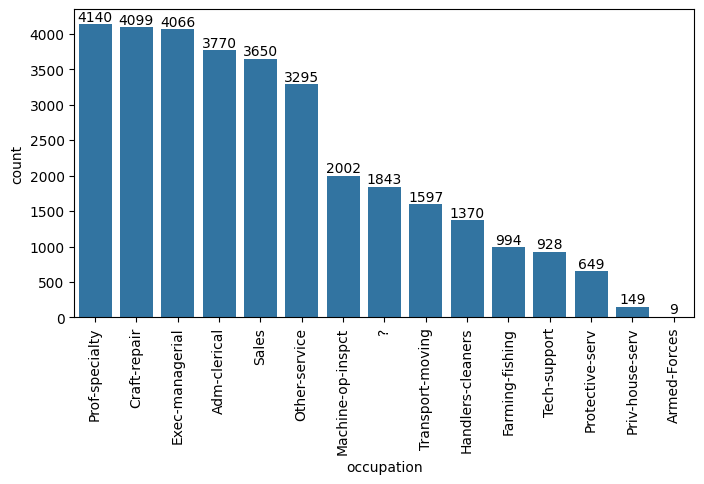

In [41]:
plt.figure(figsize=(8,4))
value=df["occupation"].value_counts().reset_index()
ax=sns.barplot(x="occupation",y="count",data=value)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=90)
plt.show()

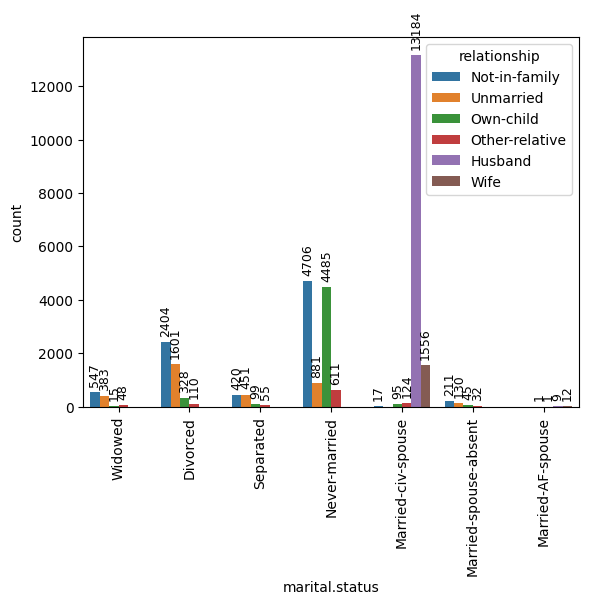

In [42]:
ax=sns.countplot(data=df,x="marital.status",hue="relationship")
for container in ax.containers:
    ax.bar_label(container,rotation=90,fontsize=9,padding =4)
plt.xticks(rotation=90)
plt.show()

# BIVARIATE & MULTIVARIATE ANALYSIS

<Axes: xlabel='age', ylabel='hours.per.week'>

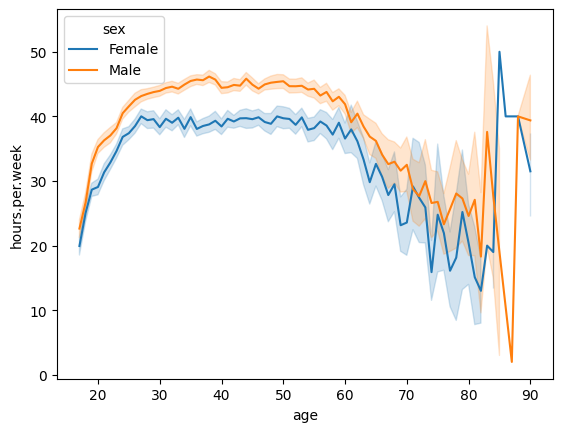

In [43]:
sns.lineplot(x="age",y="hours.per.week",data=df,hue="sex")

# 3D projection

Text(0.5, 0, 'Education_num')

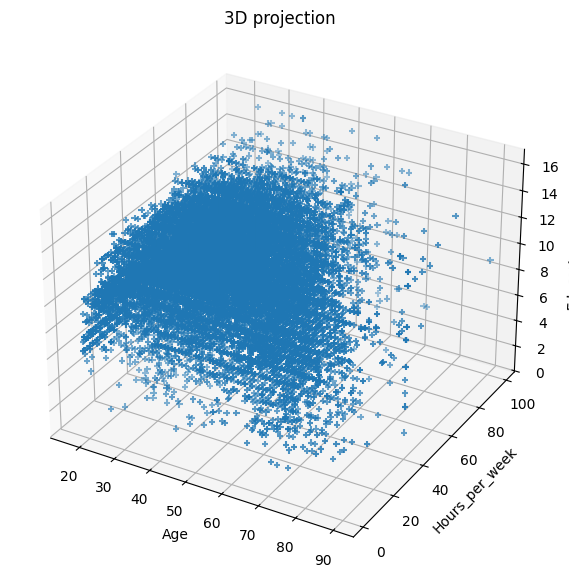

In [44]:
fig=plt.figure(figsize=(10,7))
ax=plt.subplot(projection='3d')
ax.scatter3D(df["age"],df["hours.per.week"],df["education.num"],marker='+')
ax.set_title("3D projection")

ax.set_xlabel("Age")
ax.set_ylabel("Hours_per_week")
ax.set_zlabel("Education_num")

In [45]:
df1=df.copy()
df1["sex"]=df1["sex"].replace({'Male':1,'Female':0})

/tmp/ipykernel_528/824373372.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1["sex"]=df1["sex"].replace({'Male':1,'Female':0})


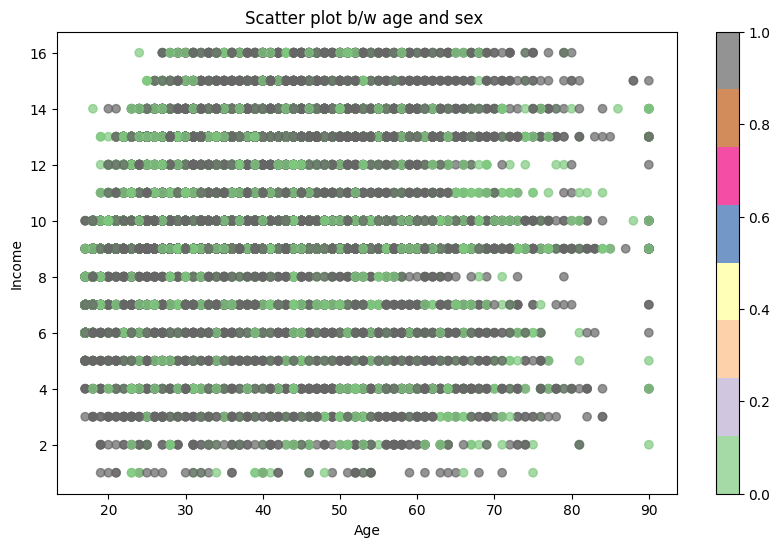

In [46]:
plt.figure(figsize=(10,6))
plt.scatter(df['age'],df['education.num'],c=df1['sex'],cmap="Accent",alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Scatter plot b/w age and sex ")
plt.colorbar()

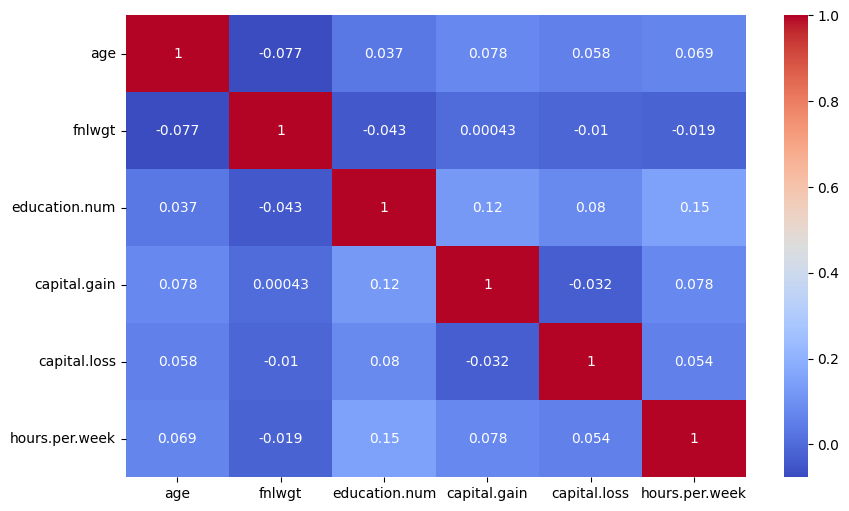

In [47]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

<Axes: xlabel='income', ylabel='education'>

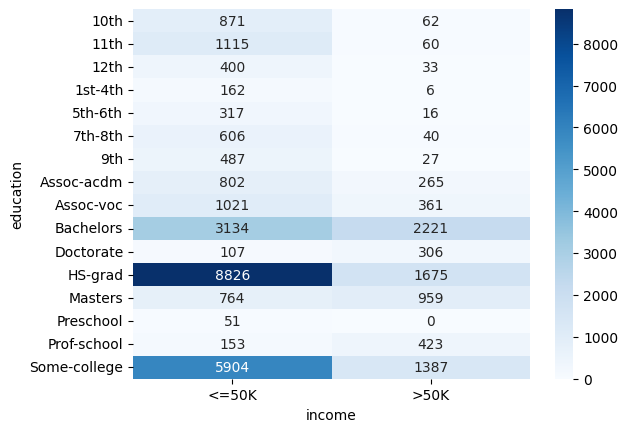

In [48]:
ct =pd.crosstab(df["education"],df["income"])
sns.heatmap(ct,annot=True,fmt="d",cmap="Blues")

<Axes: xlabel='hours.per.week', ylabel='income'>

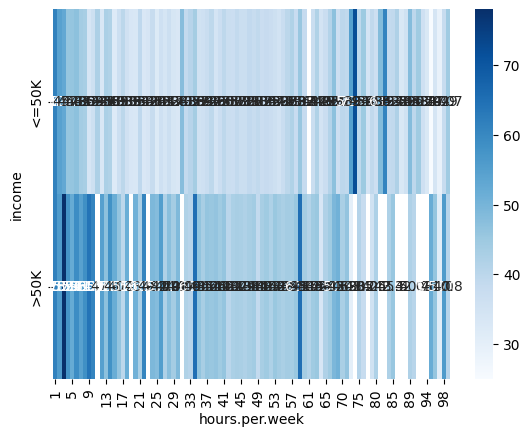

In [49]:
pivot_table=df.pivot_table(index="income",columns="hours.per.week",values="age",aggfunc="mean")
sns.heatmap(pivot_table,annot=True,fmt=".1f",cmap="Blues")


# Violinplot Plot B/W Categorical and Numerical Columns

/tmp/ipykernel_528/3446411013.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="income", y="age",palette=['red','green'])


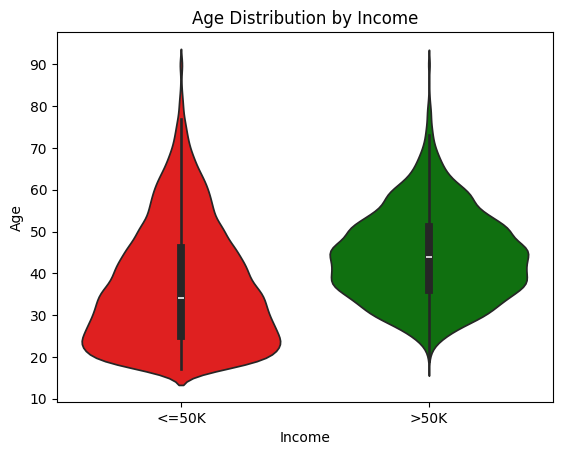

In [50]:
sns.violinplot(data=df, x="income", y="age",palette=['red','green'])
plt.title("Age Distribution by Income")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

/tmp/ipykernel_528/11066826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="education",y="age",palette=colors)


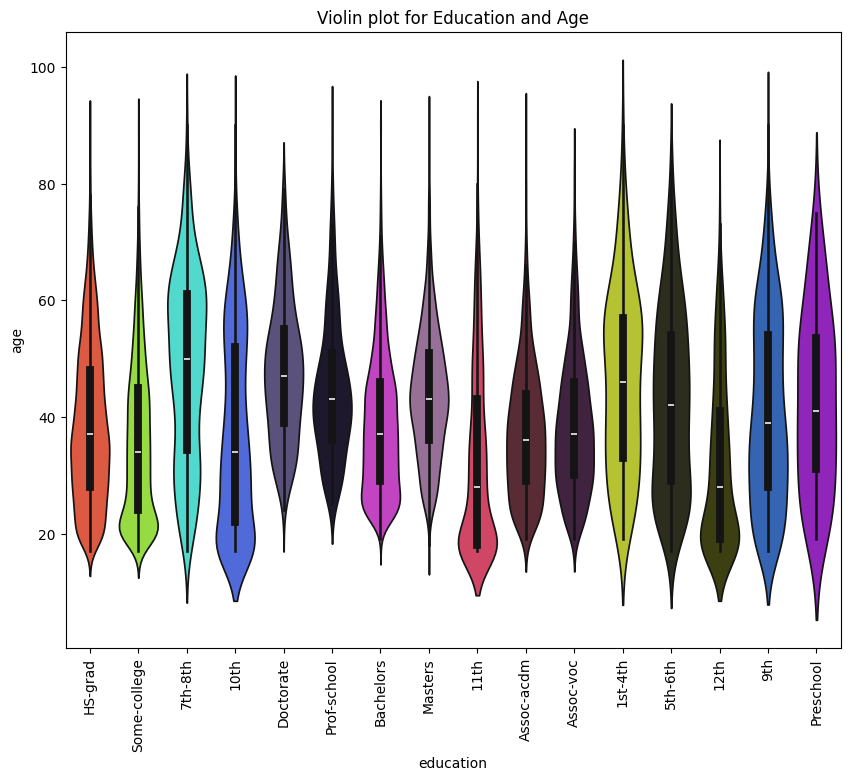

In [51]:
plt.figure(figsize=(10,8))
colors=['#F54927','#98F527','#3AF0E1','#3A5BF0','#574B82','#1B152E','#D62FD6','#9C6A9C','#E63058','#612331','#451E43','#C8DB1A','#2E301A','#42470A','#205FC7','#9A0DD1']
sns.violinplot(data=df,x="education",y="age",palette=colors)
plt.title("Violin plot for Education and Age")
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_528/4141841816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="occupation",y="hours.per.week",palette=colors)


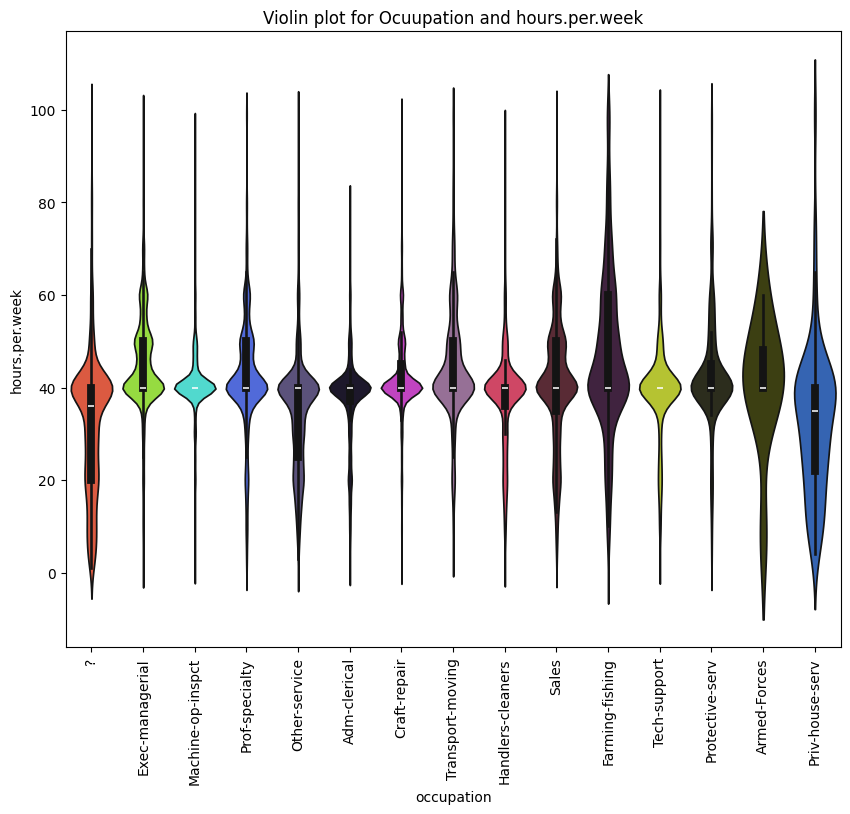

In [52]:
plt.figure(figsize=(10,8))
colors=['#F54927','#98F527','#3AF0E1','#3A5BF0','#574B82','#1B152E','#D62FD6','#9C6A9C','#E63058','#612331','#451E43','#C8DB1A','#2E301A','#42470A','#205FC7']
sns.violinplot(data=df,x="occupation",y="hours.per.week",palette=colors)
plt.xticks(rotation=90)
plt.title("Violin plot for Ocuupation and hours.per.week")
plt.show()

# use plotly plot

In [53]:
import plotly.express as px
import plotly.graph_objects as go

In [54]:
# trace=go.Scatter(x=df["age"],y=df["hours.per.week"],mode='markers',text=df["age"],marker={'color':'red','size':8})
# data=[trace]
# layout=go.Layout(title="Plot for age and working hours",
#                 xaxis={'title':'AGE'},
#                 yaxis={'title':'Working Hours'})
# fig=go.Figure(data=data,layout=layout)
# fig.show()

In [55]:
# trace=go.Bar(x=df['income'],y=df['age'],marker={'color':'red'})
# data=[trace]
# layout=go.Layout(title="Plot for income and working hour",
#                 xaxis={'title':'Income'},yaxis={'title':'Age'})
# fig=go.Figure(data=data,layout=layout)
# fig.show()

# Prepare and clean data

__Observe Outliers__

In [56]:
df.drop(columns=['fnlwgt'],inplace=True)

In [57]:
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# PLOT HISTPLOT AND BOX PLOT

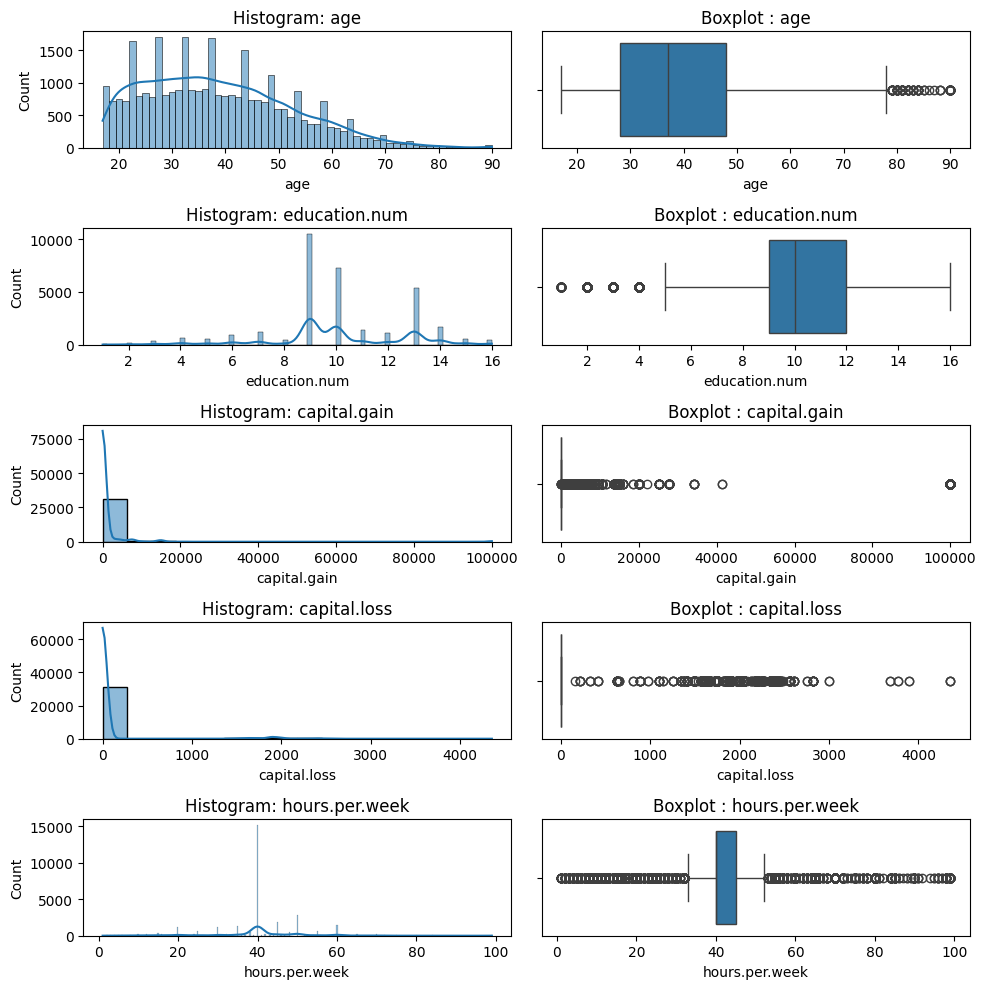

In [58]:
num_col=df.select_dtypes(include='number').columns
plt.figure(figsize=(10,10))

for i,col in enumerate(num_col):
    # for histplot
    plt.subplot(len(num_col),2,2*i+1);
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram: {col}")

    #for Boxplot
    plt.subplot(len(num_col),2,2*i+2);
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot : {col}")

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

In [59]:
df.head(10)

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


____First handle the "?" sign____

In [60]:
(df == '?').sum()

,0
age,0
workclass,1836
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0
capital.gain,0


In [61]:
df=df.replace('?',np.nan)

In [62]:
df.isnull().sum()

,0
age,0
workclass,1836
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0
capital.gain,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   education       32561 non-null  object
 3   education.num   32561 non-null  int64 
 4   marital.status  32561 non-null  object
 5   occupation      30718 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  31978 non-null  object
 13  income          32561 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


_______Split data library______

In [64]:
from sklearn.model_selection import train_test_split

_____Convert target column categorical to numerical____

In [65]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y = le.fit_transform(df['income'])
X = df.drop('income', axis=1)

In [66]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

_______Extract categorical and Numerical column______

In [67]:
cat_col=x_train.select_dtypes(include='object').columns.to_list()
num_col=x_train.select_dtypes(include='int64').columns.to_list()

__________________Make pipeline________________

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

cat_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy="most_frequent")),
    ("Encode",OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline=Pipeline([
    ("num_impute",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

final_pipeline=ColumnTransformer([
    ("cat",cat_pipeline,cat_col),
    ("num",num_pipeline,num_col)
])


______________________Now Select different Model______________________

In [69]:
from sklearn.linear_model import LogisticRegression
model =Pipeline([
    ("final",final_pipeline),
    ("classifier",LogisticRegression(max_iter=1000))
])

In [70]:
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [71]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
accuracy_score(y_test,y_pred)

0.852141870105942

In [72]:
confusion_matrix(y_test,y_pred)

array([[4608,  337],
       [ 626,  942]])

__________________PLOT CONFUSION MATRIX__________________

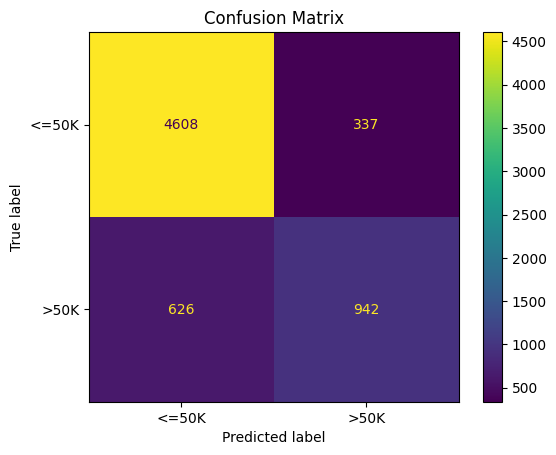

In [73]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=le.classes_)
plt.title("Confusion Matrix")
plt.show()

In [74]:
le.classes_

array(['<=50K', '>50K'], dtype=object)

____________________IMPROVE MODEL ACCURACY____________________

In [75]:
y_pred_train = model.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.851389742014742
Test Accuracy: 0.852141870105942


# Apply Grid Search CV

In [76]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
pramas={
    "classifier__C":[0.01,0.1,1,10,100]
}

grid=GridSearchCV(
    estimator=model,
    param_grid=pramas,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train,y_train)

print("Best Parameter:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

best_model=grid.best_estimator_
y_pred=best_model.predict(x_test)
print("Test Accuracy:",accuracy_score(y_test,y_pred))

Best Parameter: {'classifier__C': 1}
Best CV Score: 0.8495086276557368
Test Accuracy: 0.852141870105942


In [89]:
lr_test_acc = accuracy_score(y_test, y_pred)
print("Logistics regression :", lr_test_acc)

Logistics regression : 0.852141870105942


# Apply Decision Tree Classification

In [77]:
from sklearn.tree import DecisionTreeClassifier
dt_model =Pipeline([
    ("final",final_pipeline),
    ("classifier",DecisionTreeClassifier(random_state=42))
])
dt_model.fit(x_train,y_train)
y_pred_dt=dt_model.predict(x_test)

print("Decision Tree Accuracy :", accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy : 0.8172884999232305


In [78]:
y_pred_train_dt = dt_model.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train_dt)
test_acc = accuracy_score(y_test, y_pred_dt)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9780789312039312
Test Accuracy: 0.8172884999232305


____________APPLY GCV____________

In [79]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
params_dt={
    "classifier__max_depth":[3,5,10,15,20,None],
    "classifier__min_samples_split":[2,5,10],
    "classifier__min_samples_leaf":[1,2,5]
}

grid=GridSearchCV(
    estimator=dt_model,
    param_grid=params_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid.fit(x_train,y_train)

print("Best Parameter:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

best_dt=grid.best_estimator_
y_pred_dt=best_dt.predict(x_test)
print("Test Accuracy:",accuracy_score(y_test,y_pred_dt))

Best Parameter: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
Best CV Score: 0.8585687992397626
Test Accuracy: 0.8561338860740059


In [87]:
dt_test_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Classifier:", dt_test_acc)

Decision Tree Classifier: 0.8561338860740059


# APPLY RANDOM FOREST CLASSIFIER

In [81]:
from sklearn.ensemble import RandomForestClassifier
rd_model =Pipeline([
    ("final",final_pipeline),
    ("classifier",RandomForestClassifier(random_state=42,n_jobs=-1))
])
rd_model.fit(x_train,y_train)
y_pred_rd=rd_model.predict(x_test)

print("Decision Tree Accuracy :", accuracy_score(y_test,y_pred_rd))

print("_________________________Check the model do good or not_____________________________")
y_pred_train_rd = rd_model.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train_rd)
test_acc = accuracy_score(y_test, y_pred_rd)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("_____________________________Apply Grid search cv_____________________")
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
params_rd={
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[10,20,None],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

grid_rd=GridSearchCV(
    estimator=rd_model,
    param_grid=params_rd,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rd.fit(x_train,y_train)

print("Best Parameter:",grid_rd.best_params_)
print("Best CV Score:",grid_rd.best_score_)

best_rd=grid_rd.best_estimator_
y_pred_rd=best_rd.predict(x_test)
print("Test Accuracy:",accuracy_score(y_test,y_pred_rd))


Decision Tree Accuracy : 0.8432366037156457
_________________________Check the model do good or not_____________________________
Train Accuracy: 0.9780789312039312
Test Accuracy: 0.8432366037156457
_____________________________Apply Grid search cv_____________________
Best Parameter: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV Score: 0.8655173148201714
Test Accuracy: 0.8630431444802702


In [84]:
rd_test_acc = accuracy_score(y_test, y_pred_rd)
print("Random Forest Test Accuracy:", rd_test_acc)

Random Forest Test Accuracy: 0.8630431444802702


**Make Classification Report for Random Forest Model**

In [93]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_rd,target_names=le.classes_))

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4945
        >50K       0.77      0.61      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.78      0.80      6513
weighted avg       0.86      0.86      0.86      6513



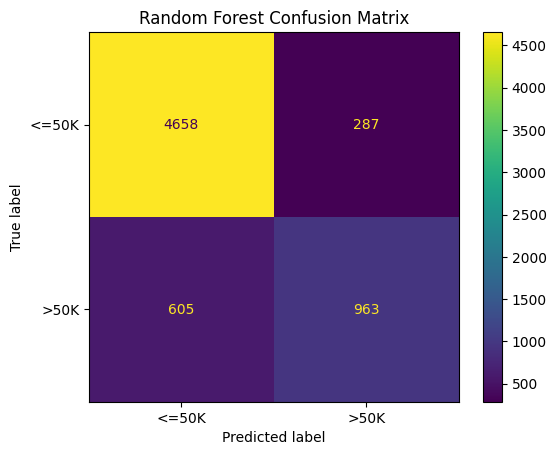

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rd,
    display_labels=le.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.show()

**Support Vector Classifier (SVC)**

In [92]:
from sklearn.svm import SVC
SVC_model =Pipeline([
    ("final",final_pipeline),
    ("classifier",SVC())
])
SVC_model.fit(x_train,y_train)
y_pred_SVC=SVC_model.predict(x_test)

print("Support Vector Classifier :", accuracy_score(y_test,y_pred_SVC))

print("_________________________Check the model do good or not_____________________________")
y_pred_train_SVC = SVC_model.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train_SVC)
test_acc = accuracy_score(y_test, y_pred_SVC)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("_____________________________Apply Grid search cv_____________________")
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
params_SVC={
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"]
}

grid_SVC=GridSearchCV(
    estimator=SVC_model,
    param_grid=params_SVC,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_SVC.fit(x_train,y_train)

print("Best Parameter:",grid_SVC.best_params_)
print("Best CV Score:",grid_SVC.best_score_)

best_SVC=grid_SVC.best_estimator_
y_pred_SVC=best_SVC.predict(x_test)
print("Test Accuracy:",accuracy_score(y_test,y_pred_SVC))

SVC_test_acc = accuracy_score(y_test, y_pred_SVC)
print("Support Vector Classifier Test Accuracy:", SVC_test_acc)

Support Vector Classifier : 0.8552126516198373
_________________________Check the model do good or not_____________________________
Train Accuracy: 0.8666308353808354
Test Accuracy: 0.8552126516198373
_____________________________Apply Grid search cv_____________________
Best Parameter: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best CV Score: 0.8561117790742363
Test Accuracy: 0.8552126516198373
Support Vector Classifier Test Accuracy: 0.8552126516198373


In [95]:
result={
    "Logistic Regression":lr_test_acc,
    "Decision Tree":dt_test_acc,
    "Random Forest":rd_test_acc,
    "Support Vector Classifier":SVC_test_acc
}

for model.name,accuracy in result.items():
    print(f"{model.name} : {accuracy}")

Logistic Regression : 0.852141870105942
Decision Tree : 0.8561338860740059
Random Forest : 0.8630431444802702
Support Vector Classifier : 0.8552126516198373


***At the end Rnadom forest do best !!!!***

# Save the model

In [96]:
import joblib
joblib.dump(best_rd,"adult_census_income_prediction.joblib")
joblib.dump(le,"label_encoder.joblib")

['label_encoder.joblib']

In [97]:
import sklearn
print(sklearn.__version__)

1.6.1
